<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 11 </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [2]:
df = pd.read_csv('StudentsPerformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [4]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Step 4: Display PairPlot

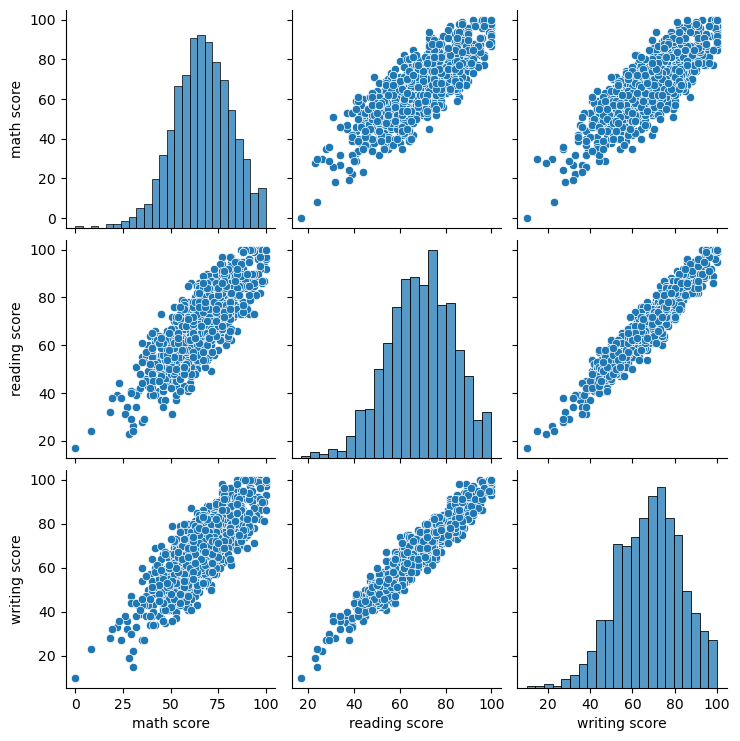

In [6]:
sns.pairplot(df)

# Step 6: Distribution of numerical features

In [7]:
numeric_df = df[['math score',
                 'reading score',
                 'writing score']]

numeric_df.head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


# Step 5: Correlation heatmap

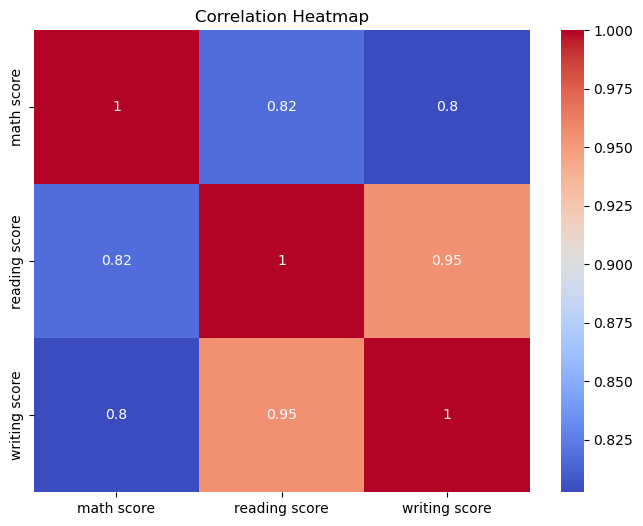

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Step 7: Apply StandardScaler  and Prepare Data for Clustering

In [9]:
X = numeric_df


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.39002351  0.19399858  0.39149181]
 [ 0.19207553  1.42747598  1.31326868]
 [ 1.57771141  1.77010859  1.64247471]
 [-1.25954302 -0.83389925 -1.58374436]
 [ 0.65395415  0.60515772  0.45733301]]


# Step 8: Elbow method to find optimal k

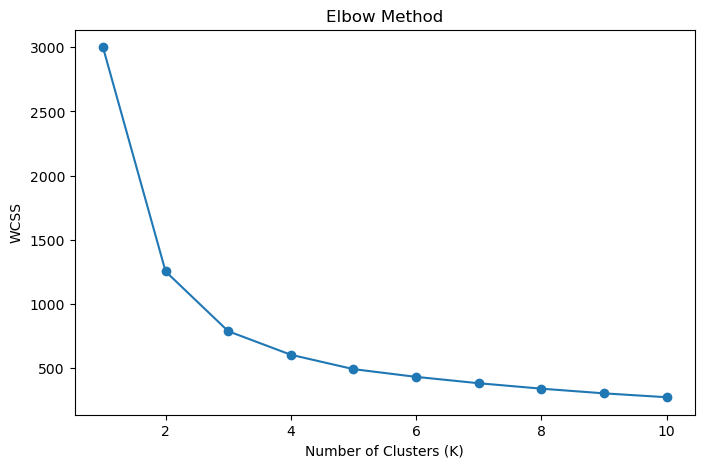

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [11]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df[['math score',
    'reading score',
    'writing score',
    'Cluster']].head()

,math score,reading score,writing score,Cluster
0,72,72,74,0
1,69,90,88,2
2,90,95,93,2
3,47,57,44,1
4,76,78,75,2


# Step 10: Print Cluster Center

In [12]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers = pd.DataFrame(
    centers,
    columns=['math score',
             'reading score',
             'writing score']
)

print(cluster_centers)

   math score  reading score  writing score
0   65.338600      68.458239      67.821670
1   48.096386      50.670683      48.485944
2   81.714286      85.146104      84.207792


# Step 11: Plot Cluster

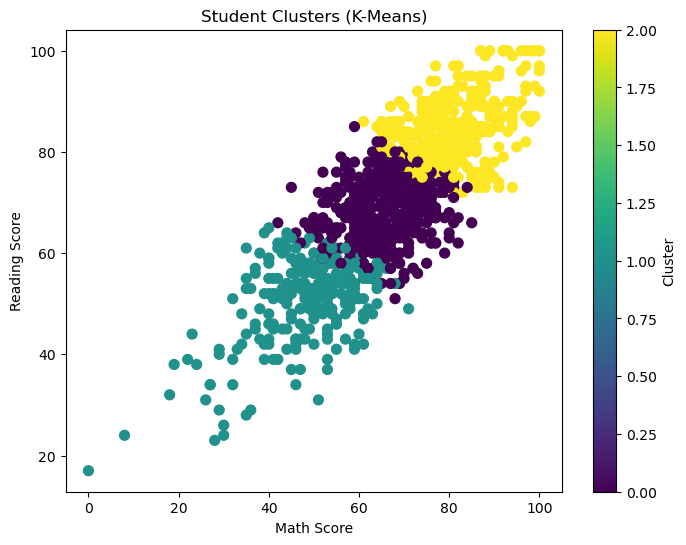

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['math score'],
    df['reading score'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Student Clusters (K-Means)")
plt.colorbar(label="Cluster")
plt.show()

# Step 12:Analyze clusters 

In [14]:
cluster_analysis = df.groupby('Cluster')[[
    'math score',
    'reading score',
    'writing score'
]].mean()

print(cluster_analysis)

         math score  reading score  writing score
Cluster                                          
0         65.338600      68.458239      67.821670
1         48.096386      50.670683      48.485944
2         81.714286      85.146104      84.207792


# Step 13: Perform K-Medoids

In [15]:
from sklearn_extra.cluster import KMedoids

kmedoids = KMedoids(
    n_clusters=3,
    random_state=42
)

kmedoid_labels = kmedoids.fit_predict(X_scaled)

df['KMedoids_Cluster'] = kmedoid_labels

print(df[['Cluster','KMedoids_Cluster']].head())

   Cluster  KMedoids_Cluster
0        0                 0
1        2                 2
2        2                 2
3        1                 1
4        2                 0


# Step:14 Comparison of K-means and K-medoids Clusters

In [16]:
comparison = pd.crosstab(
    df['Cluster'],
    df['KMedoids_Cluster']
)

comparison

KMedoids_Cluster,0,1,2
Cluster,,,
0,372,71,0
1,0,249,0
2,24,0,284


# Step: 15 | USE KMEAN++


In [17]:
kmeans_pp = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

labels_pp = kmeans_pp.fit_predict(X_scaled)

df['KMeansPP_Cluster'] = labels_pp

print(df[['KMeansPP_Cluster']].head())

   KMeansPP_Cluster
0                 0
1                 2
2                 2
3                 1
4                 2


In [23]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.4059950406533777


# Import Statement

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Plot Dendogram

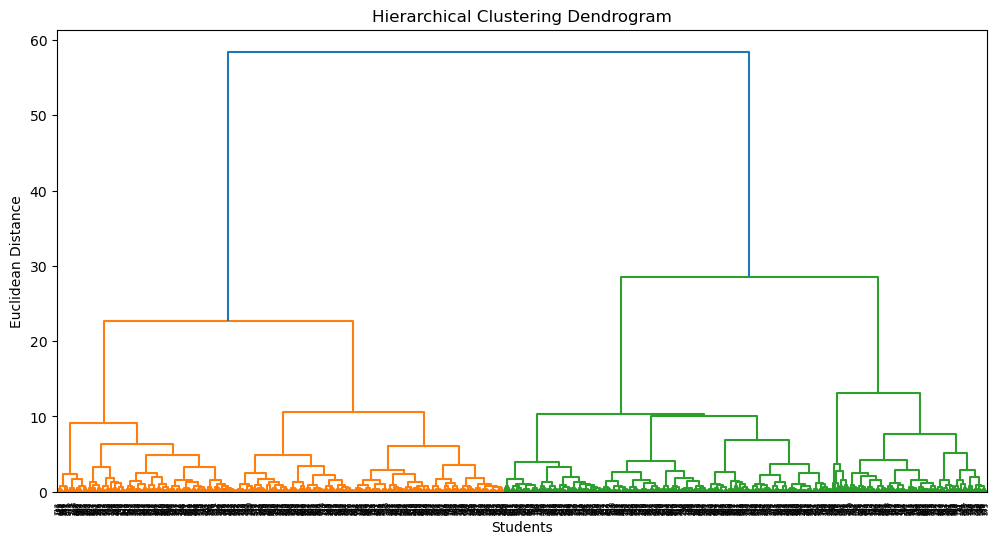

In [19]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(X_scaled, method='ward')
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Students")
plt.ylabel("Euclidean Distance")

plt.show()

# Apply Hierarchical Clustering (Choose 3 Clusters)

In [23]:
Z = linkage(X_scaled, method='ward')

clusters = fcluster(
    Z,
    t=3,
    criterion='maxclust'
)

df['Cluster'] = clusters

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Cluster,KMedoids_Cluster,KMeansPP_Cluster
0,female,group B,bachelor's degree,standard,none,72,72,74,1,0,0
1,female,group C,some college,standard,completed,69,90,88,1,2,2
2,female,group B,master's degree,standard,none,90,95,93,1,2,2
3,male,group A,associate's degree,free/reduced,none,47,57,44,3,1,1
4,male,group C,some college,standard,none,76,78,75,1,0,2


# Silhouette Score

In [24]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.3736840558540729


# Note on hierarchical clustering method

Hierarchical Clustering was applied on the Students Performance dataset using Ward linkage method.
The dendrogram suggested 3 clusters.
Students were grouped into low, medium, and high performance categories.
The clustering quality was evaluated using Silhouette Score.

Difference between K-Means and Hierarchical Clustering?
-K-Means requires K beforehand.
-Hierarchical Clustering uses a dendrogram to determine clusters.

What are the two types of Hierarchical Clustering?
-Agglomerative (Bottom-Up)
-Divisive (Top-Down)

What is Ward Linkage?
Ward linkage is a hierarchical clustering method that merges clusters in a way that minimizes the increase in within-cluster variance. It generally produces compact and well-separated clusters.

Why is Ward method commonly used?
Because it usually creates balanced, compact clusters and often gives better results for numerical datasets like StudentsPerformance.csv.

What is linkage()?
linkage() calculates the distance between observations and creates a hierarchy of clusters.

What is dendrogram()?
dendrogram() visualizes the hierarchical clustering process as a tree structure.

What is fcluster()?
fcluster() extracts the final clusters from the hierarchical clustering tree and assigns cluster labels to data points.